# Modeling

Mục tiêu của notebook này là xây dựng benchmark trước, sau đó mới huấn luyện model ML.

## 1. Naive baseline

Baseline đầu tiên: dự đoán doanh thu hôm nay bằng doanh thu cùng thứ của tuần trước.

`Revenue_pred = revenue_lag_7`

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("processed_features")

train_df = pd.read_csv(DATA_DIR / "train_features.csv", parse_dates=["Date"])
valid_df = pd.read_csv(DATA_DIR / "valid_features.csv", parse_dates=["Date"])
test_df = pd.read_csv(DATA_DIR / "test_features.csv", parse_dates=["Date"])

with open(DATA_DIR / "feature_columns.json", encoding="utf-8") as f:
    feature_meta = json.load(f)

target_col = feature_meta["target_column"]
model_target_col = feature_meta["model_target_column"]
feature_cols = feature_meta["feature_columns"]

print("Train:", train_df.shape, train_df["Date"].min().date(), "->", train_df["Date"].max().date())
print("Valid:", valid_df.shape, valid_df["Date"].min().date(), "->", valid_df["Date"].max().date())
print("Test :", test_df.shape, test_df["Date"].min().date(), "->", test_df["Date"].max().date())

Train: (1096, 37) 2013-07-04 -> 2016-07-03
Valid: (365, 37) 2016-07-04 -> 2017-07-03
Test : (546, 37) 2017-07-04 -> 2018-12-31


In [2]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_pred - y_true
    abs_error = np.abs(error)
    non_zero = y_true != 0
    smape_denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    return {
        "MAE": abs_error.mean(),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "MAPE_%": np.mean(abs_error[non_zero] / np.abs(y_true[non_zero])) * 100,
        "sMAPE_%": np.mean(np.where(smape_denominator == 0, 0, abs_error / smape_denominator)) * 100,
    }


def evaluate_naive_baseline(df, split_name):
    y_true = df[target_col]
    y_pred = df["revenue_lag_7"].clip(lower=0)
    metrics = regression_metrics(y_true, y_pred)
    metrics["split"] = split_name
    metrics["rows"] = len(df)
    return metrics


baseline_metrics = pd.DataFrame([
    evaluate_naive_baseline(valid_df, "valid"),
    evaluate_naive_baseline(test_df, "test"),
])

baseline_metrics = baseline_metrics[["split", "rows", "MAE", "RMSE", "MAPE_%", "sMAPE_%"]]
baseline_metrics

,split,rows,MAE,RMSE,MAPE_%,sMAPE_%
0,valid,365,"2,460,486.63","3,606,486.45",57.07,41.96
1,test,546,"2,028,072.45","3,061,755.55",51.70,39.56


In [3]:
valid_naive_pred = valid_df["revenue_lag_7"].clip(lower=0)

valid_naive_errors = valid_df[[
    "Date",
    "Revenue",
    "revenue_lag_7",
    "month",
    "day_of_week",
    "is_weekend",
    "has_active_promo",
]].copy()

valid_naive_errors["naive_pred"] = valid_naive_pred
valid_naive_errors["error"] = valid_naive_errors["naive_pred"] - valid_naive_errors["Revenue"]
valid_naive_errors["abs_error"] = valid_naive_errors["error"].abs()
valid_naive_errors["ape_%"] = valid_naive_errors["abs_error"] / valid_naive_errors["Revenue"] * 100

valid_naive_errors.sort_values("abs_error", ascending=False).head(10)

,Date,Revenue,revenue_lag_7,month,day_of_week,is_weekend,has_active_promo,naive_pred,error,abs_error,ape_%
276,2017-04-06,"3,991,728.43","17,516,038.82",4,3,0,1,"17,516,038.82","13,524,310.39","13,524,310.39",338.81
277,2017-04-07,"3,428,956.51","16,556,662.03",4,4,0,1,"16,556,662.03","13,127,705.52","13,127,705.52",382.85
278,2017-04-08,"3,512,061.04","15,808,755.61",4,5,1,1,"15,808,755.61","12,296,694.57","12,296,694.57",350.13
62,2016-09-04,"2,911,393.70","15,158,669.18",9,6,1,1,"15,158,669.18","12,247,275.48","12,247,275.48",420.67
340,2017-06-09,"6,070,420.59","17,528,852.88",6,4,0,0,"17,528,852.88","11,458,432.29","11,458,432.29",188.76
2,2016-07-06,"2,703,265.31","13,343,751.12",7,2,0,1,"13,343,751.12","10,640,485.81","10,640,485.81",393.62
339,2017-06-08,"7,229,728.05","17,639,270.88",6,3,0,0,"17,639,270.88","10,409,542.83","10,409,542.83",143.98
306,2017-05-06,"3,743,378.15","13,969,061.08",5,5,1,0,"13,969,061.08","10,225,682.93","10,225,682.93",273.17
337,2017-06-06,"5,342,823.74","15,437,626.24",6,1,0,0,"15,437,626.24","10,094,802.50","10,094,802.50",188.94
63,2016-09-05,"4,157,930.98","14,043,471.10",9,0,0,1,"14,043,471.10","9,885,540.12","9,885,540.12",237.75


Kết quả baseline này là mốc tối thiểu. Model ML ở bước tiếp theo cần thắng baseline `revenue_lag_7` trên validation set, đặc biệt ở MAE/RMSE và các ngày revenue peak.

## 2. Model baseline dau tien: HistGradientBoostingRegressor

Model nay dung duoc ngay tu `sklearn`, phu hop de tao ML baseline cho du lieu tabular sau feature engineering.

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor

X_train = train_df[feature_cols]
y_train_log = train_df[model_target_col]

X_valid = valid_df[feature_cols]
X_test = test_df[feature_cols]

hgb_baseline = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=300,
    l2_regularization=0.1,
    random_state=42,
)

hgb_baseline.fit(X_train, y_train_log)

valid_hgb_pred = np.expm1(hgb_baseline.predict(X_valid)).clip(min=0)
test_hgb_pred = np.expm1(hgb_baseline.predict(X_test)).clip(min=0)

print("HistGradientBoostingRegressor baseline trained.")

HistGradientBoostingRegressor baseline trained.


In [5]:
def evaluate_predictions(df, y_pred, split_name, model_name):
    metrics = regression_metrics(df[target_col], y_pred)
    metrics["model"] = model_name
    metrics["split"] = split_name
    metrics["rows"] = len(df)
    return metrics


model_metrics = pd.DataFrame([
    evaluate_predictions(valid_df, valid_naive_pred, "valid", "naive_lag_7"),
    evaluate_predictions(valid_df, valid_hgb_pred, "valid", "hist_gradient_boosting"),
    evaluate_predictions(test_df, test_df["revenue_lag_7"].clip(lower=0), "test", "naive_lag_7"),
    evaluate_predictions(test_df, test_hgb_pred, "test", "hist_gradient_boosting"),
])

model_metrics = model_metrics[["model", "split", "rows", "MAE", "RMSE", "MAPE_%", "sMAPE_%"]]
model_metrics.sort_values(["split", "MAE"])

,model,split,rows,MAE,RMSE,MAPE_%,sMAPE_%
3,hist_gradient_boosting,test,546,"838,037.67","1,159,425.22",22.77,19.53
2,naive_lag_7,test,546,"2,028,072.45","3,061,755.55",51.70,39.56
1,hist_gradient_boosting,valid,365,"931,591.53","1,373,472.18",19.05,17.72
0,naive_lag_7,valid,365,"2,460,486.63","3,606,486.45",57.07,41.96


In [6]:
valid_hgb_errors = valid_df[[
    "Date",
    "Revenue",
    "revenue_lag_7",
    "month",
    "day_of_week",
    "is_weekend",
    "has_active_promo",
]].copy()

valid_hgb_errors["hgb_pred"] = valid_hgb_pred
valid_hgb_errors["error"] = valid_hgb_errors["hgb_pred"] - valid_hgb_errors["Revenue"]
valid_hgb_errors["abs_error"] = valid_hgb_errors["error"].abs()
valid_hgb_errors["ape_%"] = valid_hgb_errors["abs_error"] / valid_hgb_errors["Revenue"] * 100

valid_hgb_errors.sort_values("abs_error", ascending=False).head(10)

,Date,Revenue,revenue_lag_7,month,day_of_week,is_weekend,has_active_promo,hgb_pred,error,abs_error,ape_%
55,2016-08-28,"15,158,669.18","6,521,389.47",8,6,1,0,"5,131,197.08","-10,027,472.10","10,027,472.10",66.15
30,2016-08-03,"9,904,285.99","7,880,563.86",8,2,0,0,"4,262,577.43","-5,641,708.56","5,641,708.56",56.96
31,2016-08-04,"9,495,153.07","10,561,338.25",8,3,0,0,"4,151,791.79","-5,343,361.28","5,343,361.28",56.27
27,2016-07-31,"11,015,269.56","4,992,598.40",7,6,1,0,"6,293,583.97","-4,721,685.59","4,721,685.59",42.86
269,2017-03-30,"17,516,038.82","8,227,253.04",3,3,0,1,"12,973,639.81","-4,542,399.01","4,542,399.01",25.93
120,2016-11-01,"7,719,179.86","4,299,274.80",11,1,0,0,"3,187,476.02","-4,531,703.84","4,531,703.84",58.71
59,2016-09-01,"12,403,544.62","8,794,928.73",9,3,0,1,"8,157,517.35","-4,246,027.27","4,246,027.27",34.23
29,2016-08-02,"9,744,357.22","7,851,989.46",8,1,0,0,"5,593,404.84","-4,150,952.38","4,150,952.38",42.60
299,2017-04-29,"13,969,061.08","5,307,716.56",4,5,1,0,"9,867,133.52","-4,101,927.56","4,101,927.56",29.36
295,2017-04-25,"8,289,377.68","8,056,843.67",4,1,0,0,"11,718,501.87","3,429,124.19","3,429,124.19",41.37


## 3. Danh gia model tren validation

Vi model baseline dang train voi target `log_revenue`, prediction can duoc dua ve revenue that bang `np.expm1` truoc khi tinh metric.

In [7]:
y_valid_true = valid_df[target_col]
y_valid_pred_log_target = np.expm1(hgb_baseline.predict(X_valid)).clip(min=0)

valid_log_target_metrics = pd.DataFrame([
    evaluate_predictions(valid_df, y_valid_pred_log_target, "valid", "hgb_log_target")
])

valid_log_target_metrics[["model", "split", "rows", "MAE", "RMSE", "MAPE_%", "sMAPE_%"]]

,model,split,rows,MAE,RMSE,MAPE_%,sMAPE_%
0,hgb_log_target,valid,365,"931,591.53","1,373,472.18",19.05,17.72


## 4. Error analysis

Phan tich loi cua model `hgb_log_target` tren validation set de xem model sai nhieu o dau.

In [8]:
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

plt.style.use("seaborn-v0_8-whitegrid")

def format_millions_axis(axis):
    axis.set_major_formatter(lambda x, pos: f"{x / 1_000_000:.1f}M")


valid_error_analysis = valid_df[[
    "Date",
    "Revenue",
    "month",
    "day_of_week",
    "is_weekend",
    "has_active_promo",
    "active_promo_count",
    "revenue_lag_7",
]].copy()

valid_error_analysis["prediction"] = valid_hgb_pred
valid_error_analysis["error"] = valid_error_analysis["prediction"] - valid_error_analysis["Revenue"]
valid_error_analysis["abs_error"] = valid_error_analysis["error"].abs()
valid_error_analysis["ape_%"] = valid_error_analysis["abs_error"] / valid_error_analysis["Revenue"] * 100
valid_error_analysis["under_predicted"] = valid_error_analysis["error"] < 0

day_name_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}
valid_error_analysis["day_name"] = valid_error_analysis["day_of_week"].map(day_name_map)
valid_error_analysis["day_type"] = np.where(valid_error_analysis["is_weekend"] == 1, "weekend", "weekday")
valid_error_analysis["promo_status"] = np.where(valid_error_analysis["has_active_promo"] == 1, "promo", "no_promo")

revenue_p90 = valid_error_analysis["Revenue"].quantile(0.90)
revenue_p95 = valid_error_analysis["Revenue"].quantile(0.95)
valid_error_analysis["revenue_peak_group"] = np.select(
    [
        valid_error_analysis["Revenue"] >= revenue_p95,
        valid_error_analysis["Revenue"] >= revenue_p90,
    ],
    ["top_5pct", "top_10pct"],
    default="normal",
)

display(valid_error_analysis.head())

,Date,Revenue,month,day_of_week,is_weekend,has_active_promo,active_promo_count,revenue_lag_7,prediction,error,abs_error,ape_%,under_predicted,day_name,day_type,promo_status,revenue_peak_group
0,2016-07-04,"1,386,571.93",7,0,0,1,1,"6,871,506.56","2,718,033.82","1,331,461.89","1,331,461.89",96.03,False,Mon,weekday,promo,normal
1,2016-07-05,"2,748,779.52",7,1,0,1,1,"8,247,984.99","2,560,737.38","-188,042.14","188,042.14",6.84,True,Tue,weekday,promo,normal
2,2016-07-06,"2,703,265.31",7,2,0,1,1,"13,343,751.12","3,421,646.08","718,380.77","718,380.77",26.57,False,Wed,weekday,promo,normal
3,2016-07-07,"4,517,288.27",7,3,0,1,1,"11,824,115.33","3,528,588.58","-988,699.69","988,699.69",21.89,True,Thu,weekday,promo,normal
4,2016-07-08,"3,773,827.56",7,4,0,1,1,"10,173,764.85","4,846,156.34","1,072,328.78","1,072,328.78",28.41,False,Fri,weekday,promo,normal


,rows,avg_revenue,avg_prediction,bias,MAE,RMSE,MAPE_percent,under_prediction_rate
0,365,"5,596,482.79","5,497,854.46","-98,628.34","931,591.53","1,373,472.18",19.05,51.78


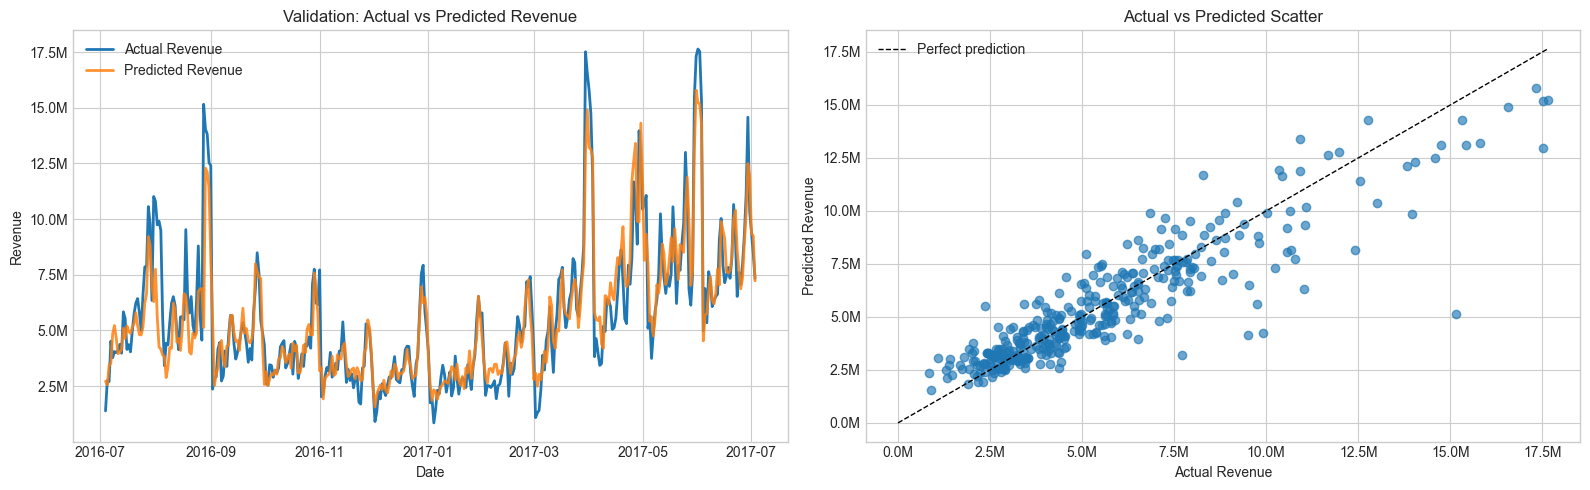

In [9]:
def summarize_errors(df, group_cols):
    summary = (
        df.groupby(group_cols, dropna=False)
        .agg(
            rows=("Revenue", "size"),
            avg_revenue=("Revenue", "mean"),
            avg_prediction=("prediction", "mean"),
            bias=("error", "mean"),
            MAE=("abs_error", "mean"),
            RMSE=("error", lambda x: np.sqrt(np.mean(x ** 2))),
            MAPE_percent=("ape_%", "mean"),
            under_prediction_rate=("under_predicted", "mean"),
        )
        .reset_index()
    )
    summary["under_prediction_rate"] = summary["under_prediction_rate"] * 100
    return summary.sort_values("MAE", ascending=False)


overall_valid_error = pd.DataFrame([{
    "rows": len(valid_error_analysis),
    "avg_revenue": valid_error_analysis["Revenue"].mean(),
    "avg_prediction": valid_error_analysis["prediction"].mean(),
    "bias": valid_error_analysis["error"].mean(),
    "MAE": valid_error_analysis["abs_error"].mean(),
    "RMSE": np.sqrt(np.mean(valid_error_analysis["error"] ** 2)),
    "MAPE_percent": valid_error_analysis["ape_%"].mean(),
    "under_prediction_rate": valid_error_analysis["under_predicted"].mean() * 100,
}])

display(overall_valid_error)

plot_df = valid_error_analysis.sort_values("Date").copy()
plot_df["Date"] = pd.to_datetime(plot_df["Date"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(plot_df["Date"], plot_df["Revenue"], label="Actual Revenue", linewidth=2)
axes[0].plot(plot_df["Date"], plot_df["prediction"], label="Predicted Revenue", linewidth=2, alpha=0.85)
axes[0].set_title("Validation: Actual vs Predicted Revenue")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Revenue")
format_millions_axis(axes[0].yaxis)
axes[0].legend()

axes[1].scatter(valid_error_analysis["Revenue"], valid_error_analysis["prediction"], alpha=0.65)
limit = max(valid_error_analysis["Revenue"].max(), valid_error_analysis["prediction"].max())
axes[1].plot([0, limit], [0, limit], linestyle="--", color="black", linewidth=1, label="Perfect prediction")
axes[1].set_title("Actual vs Predicted Scatter")
axes[1].set_xlabel("Actual Revenue")
axes[1].set_ylabel("Predicted Revenue")
format_millions_axis(axes[1].xaxis)
format_millions_axis(axes[1].yaxis)
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.1. Sai so theo thang

,month,rows,avg_revenue,avg_prediction,bias,MAE,RMSE,MAPE_percent,under_prediction_rate
7,8,31,"7,322,854.58","5,723,031.90","-1,599,822.68","1,961,605.75","2,802,234.63",24.67,83.87
3,4,30,"7,650,896.51","8,433,855.74","782,959.23","1,475,105.50","1,739,368.58",22.33,23.33
4,5,31,"8,480,930.51","8,510,386.11","29,455.60","1,315,538.88","1,598,851.48",16.48,48.39
2,3,31,"6,076,853.09","5,787,280.45","-289,572.64","1,019,568.08","1,324,414.69",26.70,61.29
5,6,30,"8,914,444.72","8,766,304.69","-148,140.03","904,053.58","1,181,392.00",9.91,53.33
6,7,31,"5,773,093.75","5,488,734.94","-284,358.82","881,456.75","1,208,425.01",17.20,61.29
8,9,30,"4,838,437.10","5,034,019.61","195,582.51","811,451.38","1,214,579.68",19.21,43.33
10,11,30,"3,503,802.64","3,464,654.80","-39,147.84","669,522.88","1,049,598.56",20.15,50.00
1,2,28,"3,927,994.98","4,094,251.18","166,256.19","615,331.21","760,602.01",19.55,42.86
0,1,31,"3,073,278.35","3,187,307.96","114,029.61","530,157.34","676,271.76",23.74,48.39


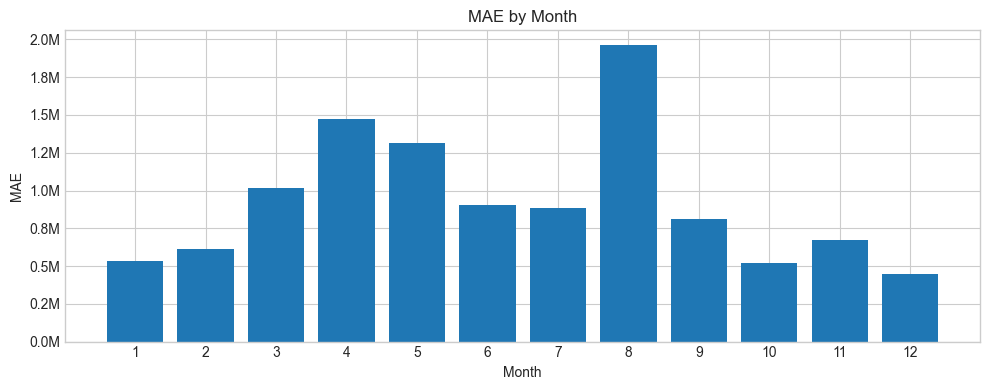

In [10]:
error_by_month = summarize_errors(valid_error_analysis, ["month"])
display(error_by_month)

month_plot = error_by_month.sort_values("month")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_plot["month"].astype(str), month_plot["MAE"])
ax.set_title("MAE by Month")
ax.set_xlabel("Month")
ax.set_ylabel("MAE")
format_millions_axis(ax.yaxis)
plt.tight_layout()
plt.show()

### 4.2. Sai so theo day_of_week

,day_of_week,day_name,rows,avg_revenue,avg_prediction,bias,MAE,RMSE,MAPE_percent,under_prediction_rate
3,3,Thu,52,"6,114,241.81","5,776,376.17","-337,865.65","1,285,673.08","1,768,898.17",22.82,50.00
2,2,Wed,52,"5,812,043.04","5,649,917.06","-162,125.98","935,781.22","1,274,912.96",23.34,53.85
6,6,Sun,52,"5,356,917.96","5,094,119.51","-262,798.44","911,658.92","1,741,127.70",16.10,51.92
5,5,Sat,52,"5,094,373.74","5,346,936.40","252,562.66","907,652.11","1,239,290.43",21.11,42.31
1,1,Tue,52,"5,816,300.57","5,527,948.37","-288,352.20","859,410.91","1,315,161.79",14.52,63.46
4,4,Fri,52,"5,428,177.55","5,663,659.36","235,481.81","854,383.64","1,113,376.88",19.50,40.38
0,0,Mon,53,"5,554,139.17","5,427,379.61","-126,759.56","769,694.22","965,557.12",16.03,60.38


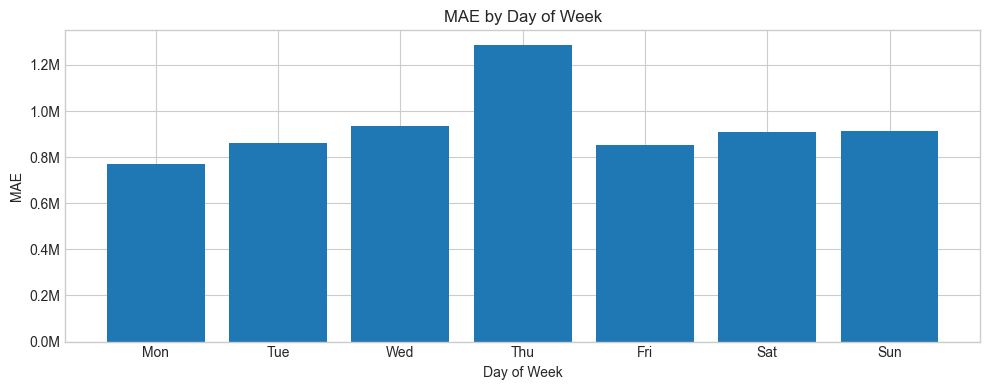

In [11]:
error_by_day_of_week = summarize_errors(valid_error_analysis, ["day_of_week", "day_name"])
display(error_by_day_of_week)

dow_plot = error_by_day_of_week.sort_values("day_of_week")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dow_plot["day_name"], dow_plot["MAE"])
ax.set_title("MAE by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("MAE")
format_millions_axis(ax.yaxis)
plt.tight_layout()
plt.show()

### 4.3. Weekend vs weekday

,day_type,rows,avg_revenue,avg_prediction,bias,MAE,RMSE,MAPE_percent,under_prediction_rate
0,weekday,261,"5,744,249.24","5,608,360.03","-135,889.20","940,332.31","1,314,584.23",19.23,53.64
1,weekend,104,"5,225,645.85","5,220,527.96","-5,117.89","909,655.52","1,511,186.03",18.61,47.12


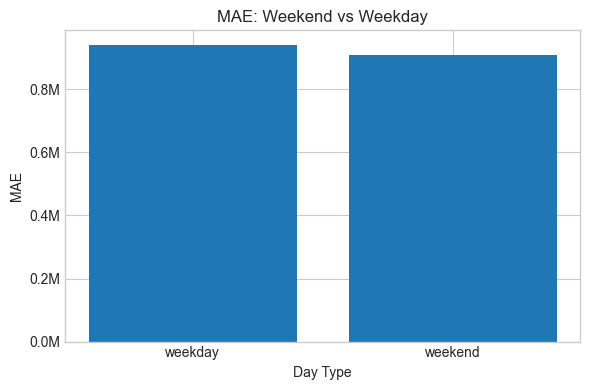

In [12]:
error_by_day_type = summarize_errors(valid_error_analysis, ["day_type"])
display(error_by_day_type)

day_type_plot = error_by_day_type.sort_values("day_type")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(day_type_plot["day_type"], day_type_plot["MAE"])
ax.set_title("MAE: Weekend vs Weekday")
ax.set_xlabel("Day Type")
ax.set_ylabel("MAE")
format_millions_axis(ax.yaxis)
plt.tight_layout()
plt.show()

### 4.4. Ngay co promotion

,promo_status,has_active_promo,rows,avg_revenue,avg_prediction,bias,MAE,RMSE,MAPE_percent,under_prediction_rate
0,no_promo,0,194,"6,061,247.92","5,808,699.43","-252,548.49","1,088,751.89","1,621,634.96",19.96,57.22
1,promo,1,171,"5,069,205.40","5,145,199.93","75,994.53","753,292.64","1,021,361.44",18.02,45.61


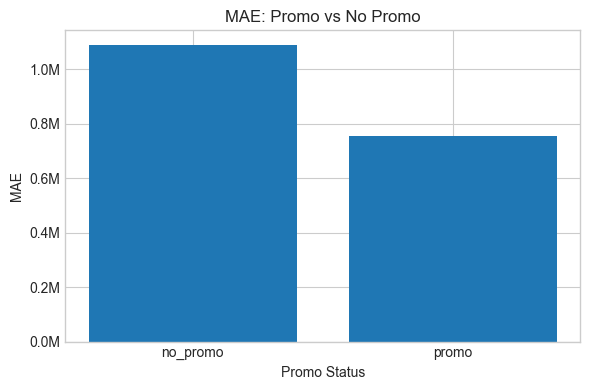

In [13]:
error_by_promo = summarize_errors(valid_error_analysis, ["promo_status", "has_active_promo"])
display(error_by_promo)

promo_plot = error_by_promo.sort_values("promo_status")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(promo_plot["promo_status"], promo_plot["MAE"])
ax.set_title("MAE: Promo vs No Promo")
ax.set_xlabel("Promo Status")
ax.set_ylabel("MAE")
format_millions_axis(ax.yaxis)
plt.tight_layout()
plt.show()

### 4.5. Ngay doanh thu cuc cao

Revenue p90: 9,769,392.98
Revenue p95: 11,924,962.53


,revenue_peak_group,rows,avg_revenue,avg_prediction,bias,MAE,RMSE,MAPE_percent,under_prediction_rate
2,top_5pct,19,"14,847,693.43","12,461,750.33","-2,385,943.11","2,633,994.46","3,321,998.89",17.77,89.47
1,top_10pct,18,"10,580,022.75","9,404,598.30","-1,175,424.45","1,973,694.11","2,415,650.73",18.73,72.22
0,normal,328,"4,787,102.54","4,880,063.57","92,961.03","775,788.17","1,067,580.67",19.14,48.48


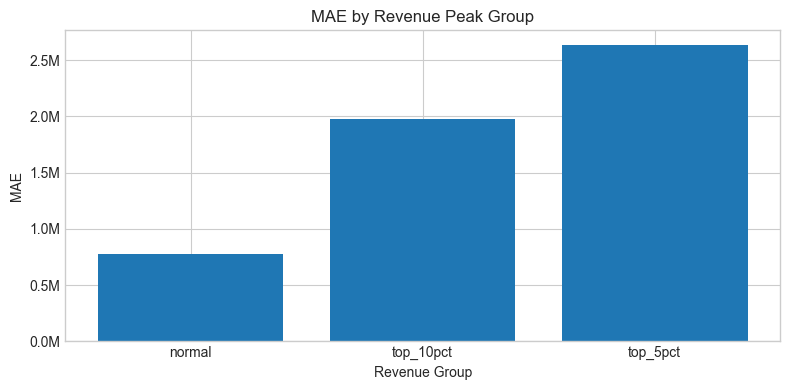

In [14]:
print(f"Revenue p90: {revenue_p90:,.2f}")
print(f"Revenue p95: {revenue_p95:,.2f}")

error_by_peak_revenue = summarize_errors(valid_error_analysis, ["revenue_peak_group"])
display(error_by_peak_revenue)

peak_order = ["normal", "top_10pct", "top_5pct"]
peak_plot = error_by_peak_revenue.set_index("revenue_peak_group").loc[peak_order].reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(peak_plot["revenue_peak_group"], peak_plot["MAE"])
ax.set_title("MAE by Revenue Peak Group")
ax.set_xlabel("Revenue Group")
ax.set_ylabel("MAE")
format_millions_axis(ax.yaxis)
plt.tight_layout()
plt.show()

In [15]:
valid_error_analysis.sort_values("Revenue", ascending=False)[[
    "Date",
    "Revenue",
    "prediction",
    "error",
    "abs_error",
    "ape_%",
    "month",
    "day_name",
    "day_type",
    "promo_status",
    "revenue_lag_7",
]].head(15)

,Date,Revenue,prediction,error,abs_error,ape_%,month,day_name,day_type,promo_status,revenue_lag_7
332,2017-06-01,"17,639,270.88","15,240,436.14","-2,398,834.74","2,398,834.74",13.60,6,Thu,weekday,no_promo,"12,997,641.60"
333,2017-06-02,"17,528,852.88","15,166,807.65","-2,362,045.23","2,362,045.23",13.48,6,Fri,weekday,no_promo,"10,924,584.92"
269,2017-03-30,"17,516,038.82","12,973,639.81","-4,542,399.01","4,542,399.01",25.93,3,Thu,weekday,promo,"8,227,253.04"
331,2017-05-31,"17,314,841.86","15,792,313.62","-1,522,528.24","1,522,528.24",8.79,5,Wed,weekday,no_promo,"9,809,118.20"
270,2017-03-31,"16,556,662.03","14,906,274.60","-1,650,387.43","1,650,387.43",9.97,3,Fri,weekday,promo,"8,043,513.70"
271,2017-04-01,"15,808,755.61","13,221,908.81","-2,586,846.80","2,586,846.80",16.36,4,Sat,weekend,promo,"5,949,599.34"
330,2017-05-30,"15,437,626.24","13,102,717.72","-2,334,908.52","2,334,908.52",15.12,5,Tue,weekday,no_promo,"8,875,094.41"
334,2017-06-03,"15,308,256.14","14,287,518.72","-1,020,737.42","1,020,737.42",6.67,6,Sat,weekend,no_promo,"6,842,735.97"
55,2016-08-28,"15,158,669.18","5,131,197.08","-10,027,472.10","10,027,472.10",66.15,8,Sun,weekend,no_promo,"6,521,389.47"
272,2017-04-02,"14,750,037.65","13,126,974.27","-1,623,063.38","1,623,063.38",11.00,4,Sun,weekend,promo,"5,631,526.96"


### 4.6. Nhung ngay model sai nhieu nhat

,Date,Revenue,prediction,error,abs_error,ape_%,month,day_name,day_type,promo_status,revenue_lag_7
55,2016-08-28,"15,158,669.18","5,131,197.08","-10,027,472.10","10,027,472.10",66.15,8,Sun,weekend,no_promo,"6,521,389.47"
30,2016-08-03,"9,904,285.99","4,262,577.43","-5,641,708.56","5,641,708.56",56.96,8,Wed,weekday,no_promo,"7,880,563.86"
31,2016-08-04,"9,495,153.07","4,151,791.79","-5,343,361.28","5,343,361.28",56.27,8,Thu,weekday,no_promo,"10,561,338.25"
27,2016-07-31,"11,015,269.56","6,293,583.97","-4,721,685.59","4,721,685.59",42.86,7,Sun,weekend,no_promo,"4,992,598.40"
269,2017-03-30,"17,516,038.82","12,973,639.81","-4,542,399.01","4,542,399.01",25.93,3,Thu,weekday,promo,"8,227,253.04"
120,2016-11-01,"7,719,179.86","3,187,476.02","-4,531,703.84","4,531,703.84",58.71,11,Tue,weekday,no_promo,"4,299,274.80"
59,2016-09-01,"12,403,544.62","8,157,517.35","-4,246,027.27","4,246,027.27",34.23,9,Thu,weekday,promo,"8,794,928.73"
29,2016-08-02,"9,744,357.22","5,593,404.84","-4,150,952.38","4,150,952.38",42.60,8,Tue,weekday,no_promo,"7,851,989.46"
299,2017-04-29,"13,969,061.08","9,867,133.52","-4,101,927.56","4,101,927.56",29.36,4,Sat,weekend,no_promo,"5,307,716.56"
295,2017-04-25,"8,289,377.68","11,718,501.87","3,429,124.19","3,429,124.19",41.37,4,Tue,weekday,no_promo,"8,056,843.67"


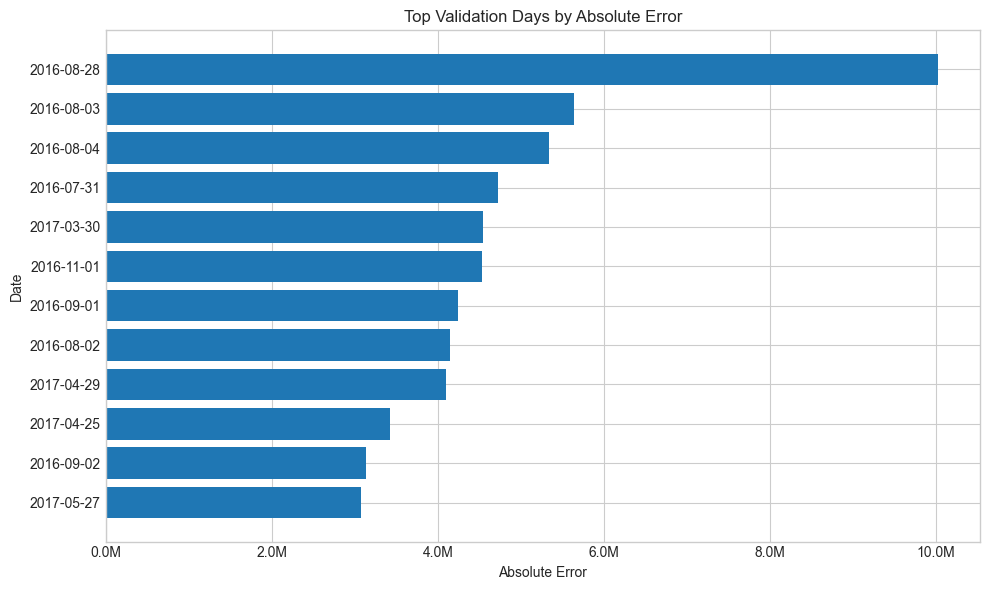

In [16]:
top_error_days = valid_error_analysis.sort_values("abs_error", ascending=False)[[
    "Date",
    "Revenue",
    "prediction",
    "error",
    "abs_error",
    "ape_%",
    "month",
    "day_name",
    "day_type",
    "promo_status",
    "revenue_lag_7",
]].head(15)

display(top_error_days)

top_error_plot = top_error_days.head(12).sort_values("abs_error").copy()
top_error_plot["date_label"] = top_error_plot["Date"].dt.strftime("%Y-%m-%d")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_error_plot["date_label"], top_error_plot["abs_error"])
ax.set_title("Top Validation Days by Absolute Error")
ax.set_xlabel("Absolute Error")
ax.set_ylabel("Date")
format_millions_axis(ax.xaxis)
plt.tight_layout()
plt.show()

## 5. Feature importance

Dùng permutation importance trên validation set. Vì model train trên `log_revenue`, scorer sẽ inverse prediction về Revenue thật bằng `np.expm1` rồi mới tính MAE.

,feature,mae_increase_mean,mae_increase_std
11,revenue_lag_1,"890,343.44","47,112.31"
15,revenue_lag_365,"390,580.75","43,509.52"
12,revenue_lag_7,"120,982.51","20,688.25"
5,day_of_month,"52,210.67","10,098.02"
13,revenue_lag_14,"44,044.56","10,724.19"
3,day_of_week,"43,346.49","10,361.10"
8,days_to_month_end,"43,055.61","12,359.54"
25,order_count_lag_1,"40,021.62","7,605.40"
7,is_month_end_4d,"30,624.04","5,560.25"
19,revenue_roll_std_7,"27,903.58","5,483.13"


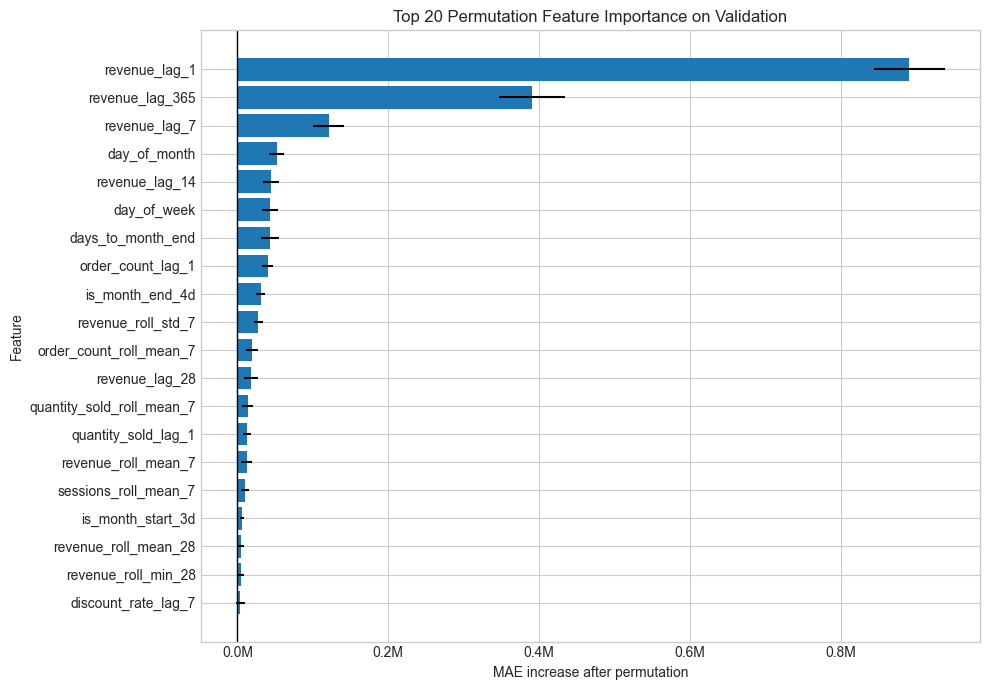

In [17]:
from sklearn.inspection import permutation_importance


def negative_mae_revenue_scorer(estimator, X, y_true):
    y_pred = np.expm1(estimator.predict(X)).clip(min=0)
    return -np.mean(np.abs(np.asarray(y_true) - y_pred))


perm_result = permutation_importance(
    hgb_baseline,
    X_valid,
    y_valid_true,
    scoring=negative_mae_revenue_scorer,
    n_repeats=20,
    random_state=42,
    n_jobs=1,
)

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "mae_increase_mean": perm_result.importances_mean,
    "mae_increase_std": perm_result.importances_std,
})

feature_importance = feature_importance.sort_values("mae_increase_mean", ascending=False)
display(feature_importance.head(20))

top_importance_plot = feature_importance.head(20).sort_values("mae_increase_mean")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_importance_plot["feature"],
    top_importance_plot["mae_increase_mean"],
    xerr=top_importance_plot["mae_increase_std"],
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Top 20 Permutation Feature Importance on Validation")
ax.set_xlabel("MAE increase after permutation")
ax.set_ylabel("Feature")
format_millions_axis(ax.xaxis)
plt.tight_layout()
plt.show()

,feature_group,feature_count,total_positive_mae_increase,avg_mae_increase,max_mae_increase
5,revenue_lag,5,"1,464,031.48","292,806.30","890,343.44"
0,calendar,9,"178,263.17","19,807.02","52,210.67"
2,order_count,2,"58,895.77","29,447.88","40,021.62"
6,revenue_rolling,7,"50,083.09","5,234.34","27,903.58"
4,quantity_sold,2,"26,074.10","13,037.05","13,400.78"
7,sessions,2,"13,959.71","6,979.85","9,981.85"
1,discount,1,"4,081.73","4,081.73","4,081.73"
3,promo,2,"2,800.41","1,400.21","2,800.41"


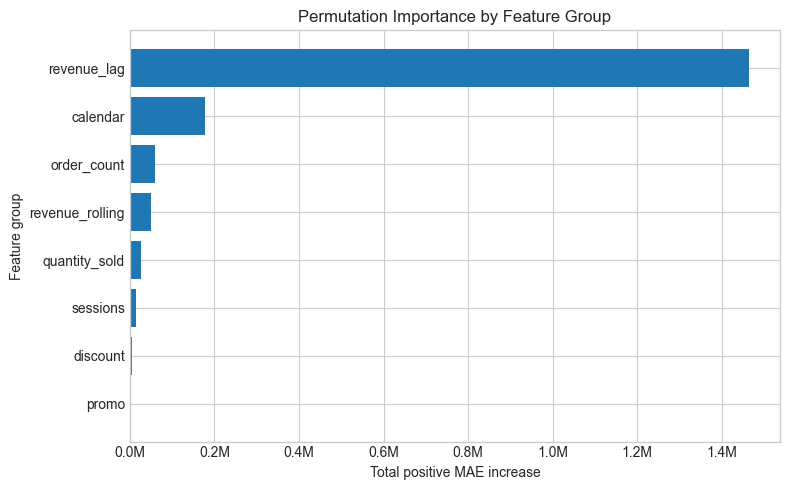

In [18]:
def assign_feature_group(feature):
    if feature.startswith("revenue_lag"):
        return "revenue_lag"
    if feature.startswith("revenue_roll"):
        return "revenue_rolling"
    if "promo" in feature:
        return "promo"
    if feature in [
        "year",
        "month",
        "quarter",
        "day_of_week",
        "is_weekend",
        "day_of_month",
        "is_month_start_3d",
        "is_month_end_4d",
        "days_to_month_end",
    ]:
        return "calendar"
    if feature.startswith("sessions"):
        return "sessions"
    if feature.startswith("order_count"):
        return "order_count"
    if feature.startswith("quantity_sold"):
        return "quantity_sold"
    if feature.startswith("discount_rate"):
        return "discount"
    return "other"


feature_importance["feature_group"] = feature_importance["feature"].apply(assign_feature_group)
feature_importance["positive_mae_increase"] = feature_importance["mae_increase_mean"].clip(lower=0)

feature_group_importance = (
    feature_importance.groupby("feature_group", as_index=False)
    .agg(
        feature_count=("feature", "size"),
        total_positive_mae_increase=("positive_mae_increase", "sum"),
        avg_mae_increase=("mae_increase_mean", "mean"),
        max_mae_increase=("mae_increase_mean", "max"),
    )
    .sort_values("total_positive_mae_increase", ascending=False)
)

display(feature_group_importance)

group_plot = feature_group_importance.sort_values("total_positive_mae_increase")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(group_plot["feature_group"], group_plot["total_positive_mae_increase"])
ax.set_title("Permutation Importance by Feature Group")
ax.set_xlabel("Total positive MAE increase")
ax.set_ylabel("Feature group")
format_millions_axis(ax.xaxis)
plt.tight_layout()
plt.show()

,feature,feature_group,mae_increase_mean,mae_increase_std
15,revenue_lag_365,revenue_lag,"390,580.75","43,509.52"
12,revenue_lag_7,revenue_lag,"120,982.51","20,688.25"
3,day_of_week,calendar,"43,346.49","10,361.10"
16,revenue_roll_mean_7,revenue_rolling,"12,116.25","6,764.77"
24,sessions_roll_mean_7,sessions,"9,981.85","5,813.16"
17,revenue_roll_mean_28,revenue_rolling,"5,046.57","3,830.36"
23,sessions_lag_1,sessions,"3,977.85","12,137.15"
9,active_promo_count,promo,"2,800.41","4,705.43"
4,is_weekend,calendar,0.00,0.00
10,has_active_promo,promo,0.00,0.00


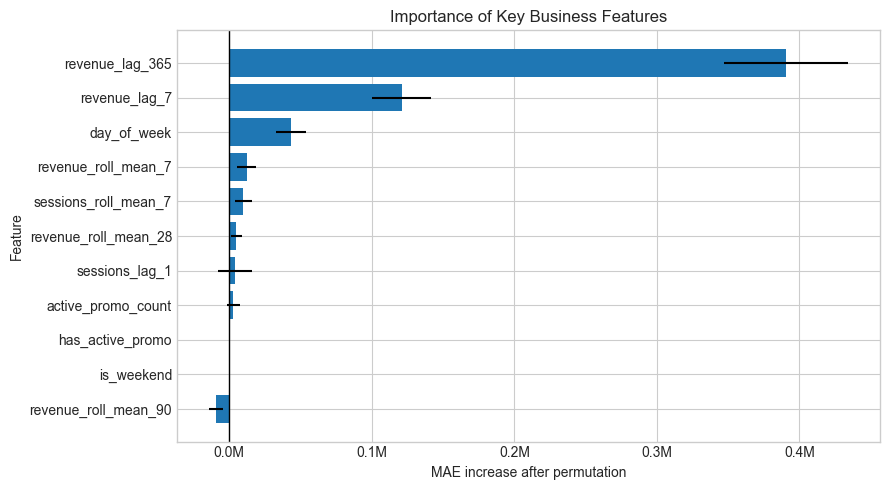

In [19]:
focus_features = [
    "revenue_lag_7",
    "revenue_lag_365",
    "revenue_roll_mean_7",
    "revenue_roll_mean_28",
    "revenue_roll_mean_90",
    "active_promo_count",
    "has_active_promo",
    "day_of_week",
    "is_weekend",
    "sessions_lag_1",
    "sessions_roll_mean_7",
]

focus_feature_importance = (
    feature_importance[feature_importance["feature"].isin(focus_features)]
    .sort_values("mae_increase_mean", ascending=False)
)

display(focus_feature_importance[[
    "feature",
    "feature_group",
    "mae_increase_mean",
    "mae_increase_std",
]])

focus_plot = focus_feature_importance.sort_values("mae_increase_mean")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(focus_plot["feature"], focus_plot["mae_increase_mean"], xerr=focus_plot["mae_increase_std"])
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Importance of Key Business Features")
ax.set_xlabel("MAE increase after permutation")
ax.set_ylabel("Feature")
format_millions_axis(ax.xaxis)
plt.tight_layout()
plt.show()

## 6. Tune model

Tune `HistGradientBoostingRegressor` sau khi da co baseline. Chi dung validation set de chon hyperparameter, khong dung test set trong buoc tuning.

In [20]:
from sklearn.model_selection import ParameterGrid


param_grid = {
    "learning_rate": [0.03, 0.05, 0.08],
    "max_iter": [200, 400],
    "max_leaf_nodes": [15, 31],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_depth": [None, 6],
}

tuning_rows = []

for params in ParameterGrid(param_grid):
    candidate = HistGradientBoostingRegressor(
        loss="squared_error",
        random_state=42,
        **params,
    )
    candidate.fit(X_train, y_train_log)

    train_pred = np.expm1(candidate.predict(X_train)).clip(min=0)
    valid_pred = np.expm1(candidate.predict(X_valid)).clip(min=0)

    train_metrics = regression_metrics(train_df[target_col], train_pred)
    valid_metrics = regression_metrics(valid_df[target_col], valid_pred)

    tuning_rows.append({
        **params,
        "train_MAE": train_metrics["MAE"],
        "train_RMSE": train_metrics["RMSE"],
        "train_MAPE_%": train_metrics["MAPE_%"],
        "valid_MAE": valid_metrics["MAE"],
        "valid_RMSE": valid_metrics["RMSE"],
        "valid_MAPE_%": valid_metrics["MAPE_%"],
        "valid_sMAPE_%": valid_metrics["sMAPE_%"],
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("valid_MAE").reset_index(drop=True)
display(tuning_results.head(10))

baseline_valid_mae = model_metrics.query("model == 'hist_gradient_boosting' and split == 'valid'")["MAE"].iloc[0]
best_valid_mae = tuning_results.loc[0, "valid_MAE"]

print(f"Baseline valid MAE: {baseline_valid_mae:,.2f}")
print(f"Best tuned valid MAE: {best_valid_mae:,.2f}")
print(f"Improvement: {baseline_valid_mae - best_valid_mae:,.2f}")

,l2_regularization,learning_rate,max_depth,max_iter,max_leaf_nodes,train_MAE,train_RMSE,train_MAPE_%,valid_MAE,valid_RMSE,valid_MAPE_%,valid_sMAPE_%
0,0.00,0.08,6.00,200,31,"296,174.41","433,892.35",6.07,"920,017.45","1,383,360.62",18.49,17.20
1,0.00,0.08,6.00,400,31,"175,196.06","263,075.55",3.46,"924,868.36","1,389,272.74",18.73,17.39
2,1.00,0.03,6.00,400,31,"346,701.44","503,353.38",7.23,"927,892.25","1,396,811.22",18.66,17.31
3,0.00,0.08,NaN,200,31,"143,003.79","236,662.44",2.86,"928,597.41","1,385,669.76",18.79,17.63
4,0.00,0.05,NaN,200,31,"238,107.39","372,390.73",4.81,"930,311.64","1,386,992.68",19.04,17.65
5,1.00,0.03,NaN,400,31,"205,407.51","327,257.41",4.12,"932,178.10","1,395,070.51",18.81,17.49
6,0.10,0.05,NaN,200,31,"241,509.87","372,478.96",4.88,"933,601.13","1,382,293.49",19.02,17.65
7,0.00,0.03,NaN,400,15,"368,577.50","540,016.01",7.59,"934,233.47","1,410,438.63",18.78,17.49
8,0.10,0.05,NaN,400,31,"108,765.39","173,690.32",2.15,"934,243.91","1,380,643.97",19.11,17.81
9,1.00,0.08,6.00,400,15,"219,737.90","327,318.10",4.35,"935,268.96","1,416,680.93",18.85,17.46


Baseline valid MAE: 931,591.53
Best tuned valid MAE: 920,017.45
Improvement: 11,574.08


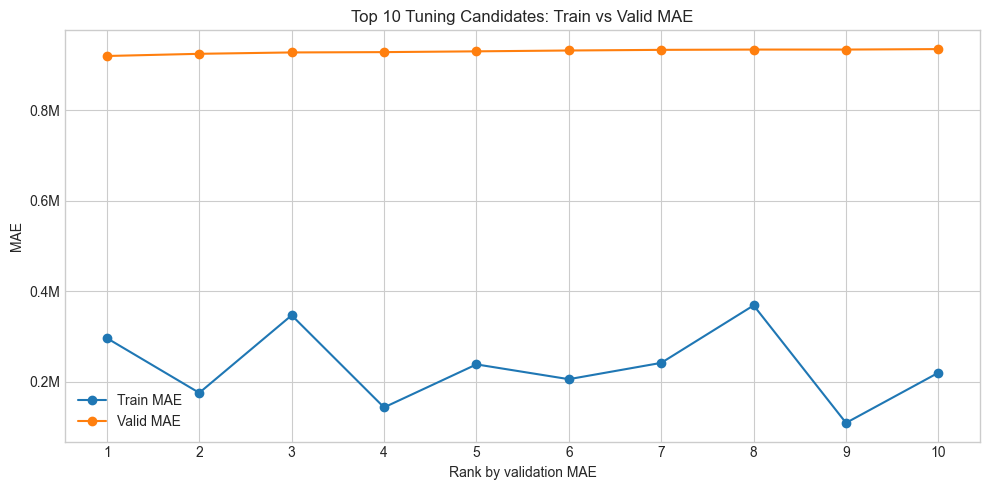

{'learning_rate': np.float64(0.08),
 'max_iter': 200,
 'max_leaf_nodes': 31,
 'l2_regularization': np.float64(0.0),
 'max_depth': 6}

In [21]:
metric_cols = ["train_MAE", "valid_MAE", "train_RMSE", "valid_RMSE", "train_MAPE_%", "valid_MAPE_%"]
param_cols = ["learning_rate", "max_iter", "max_leaf_nodes", "l2_regularization", "max_depth"]

top_tuning_plot = tuning_results.head(10).copy()
top_tuning_plot["rank"] = np.arange(1, len(top_tuning_plot) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(top_tuning_plot["rank"], top_tuning_plot["train_MAE"], marker="o", label="Train MAE")
ax.plot(top_tuning_plot["rank"], top_tuning_plot["valid_MAE"], marker="o", label="Valid MAE")
ax.set_title("Top 10 Tuning Candidates: Train vs Valid MAE")
ax.set_xlabel("Rank by validation MAE")
ax.set_ylabel("MAE")
ax.set_xticks(top_tuning_plot["rank"])
format_millions_axis(ax.yaxis)
ax.legend()
plt.tight_layout()
plt.show()

best_params = {col: tuning_results.loc[0, col] for col in param_cols}

if pd.isna(best_params["max_depth"]):
    best_params["max_depth"] = None
else:
    best_params["max_depth"] = int(best_params["max_depth"])

best_params["max_iter"] = int(best_params["max_iter"])
best_params["max_leaf_nodes"] = int(best_params["max_leaf_nodes"])

best_params

## 7. Chot model

Sau khi chon hyperparameter tot nhat tren validation set, train lai model tren `train + valid`, roi danh gia mot lan cuoi tren test set.

In [22]:
train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)

X_train_valid = train_valid_df[feature_cols]
y_train_valid_log = train_valid_df[model_target_col]

final_model = HistGradientBoostingRegressor(
    loss="squared_error",
    random_state=42,
    **best_params,
)

final_model.fit(X_train_valid, y_train_valid_log)

final_train_valid_pred = np.expm1(final_model.predict(X_train_valid)).clip(min=0)
final_test_pred = np.expm1(final_model.predict(X_test)).clip(min=0)

final_metrics = pd.DataFrame([
    evaluate_predictions(train_valid_df, final_train_valid_pred, "train_valid", "final_hgb_tuned"),
    evaluate_predictions(test_df, final_test_pred, "test", "final_hgb_tuned"),
    evaluate_predictions(test_df, test_df["revenue_lag_7"].clip(lower=0), "test", "naive_lag_7"),
    evaluate_predictions(test_df, test_hgb_pred, "test", "baseline_hgb_train_only"),
])

final_metrics = final_metrics[["model", "split", "rows", "MAE", "RMSE", "MAPE_%", "sMAPE_%"]]
display(final_metrics.sort_values(["split", "MAE"]))

,model,split,rows,MAE,RMSE,MAPE_%,sMAPE_%
1,final_hgb_tuned,test,546,"745,908.73","1,046,175.89",19.28,17.25
3,baseline_hgb_train_only,test,546,"838,037.67","1,159,425.22",22.77,19.53
2,naive_lag_7,test,546,"2,028,072.45","3,061,755.55",51.70,39.56
0,final_hgb_tuned,train_valid,1461,"327,862.49","487,585.57",6.50,6.45


,Date,Revenue,revenue_lag_7,prediction,error,abs_error,ape_%
330,2018-05-30,"20,905,271.35","11,779,004.94","15,214,542.52","-5,690,728.83","5,690,728.83",27.22
420,2018-08-28,"12,207,075.48","5,971,341.33","7,602,288.92","-4,604,786.56","4,604,786.56",37.72
332,2018-06-01,"19,245,165.78","6,498,399.18","14,872,088.88","-4,373,076.90","4,373,076.90",22.72
333,2018-06-02,"17,529,108.34","5,600,677.63","13,686,132.41","-3,842,975.93","3,842,975.93",21.92
271,2018-04-01,"9,326,921.27","4,970,364.06","13,093,942.98","3,767,021.71","3,767,021.71",40.39
425,2018-09-02,"2,926,208.13","4,717,920.92","6,591,424.37","3,665,216.24","3,665,216.24",125.25
28,2017-08-01,"7,103,485.92","7,277,905.64","10,718,428.33","3,614,942.41","3,614,942.41",50.89
32,2017-08-05,"1,626,028.13","7,623,158.15","4,968,478.64","3,342,450.51","3,342,450.51",205.56
391,2018-07-30,"7,314,460.76","6,121,614.15","10,514,246.54","3,199,785.78","3,199,785.78",43.75
325,2018-05-25,"6,498,399.18","7,337,944.43","9,606,143.14","3,107,743.96","3,107,743.96",47.82


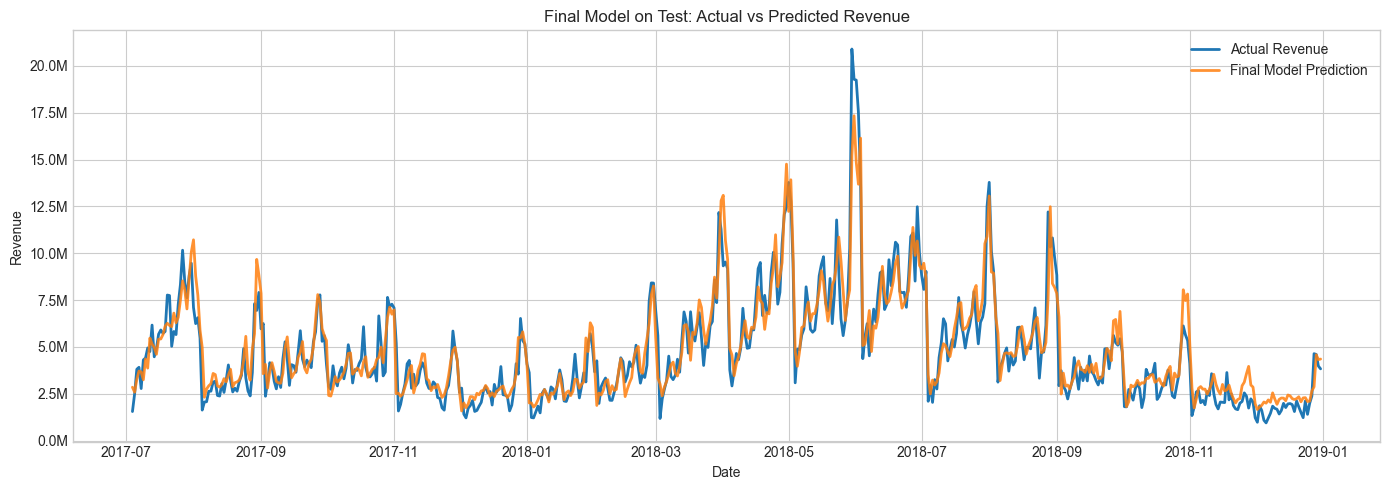

In [23]:
final_test_predictions = test_df[["Date", "Revenue", "revenue_lag_7"]].copy()
final_test_predictions["prediction"] = final_test_pred
final_test_predictions["error"] = final_test_predictions["prediction"] - final_test_predictions["Revenue"]
final_test_predictions["abs_error"] = final_test_predictions["error"].abs()
final_test_predictions["ape_%"] = final_test_predictions["abs_error"] / final_test_predictions["Revenue"] * 100

display(final_test_predictions.sort_values("abs_error", ascending=False).head(15))

plot_df = final_test_predictions.sort_values("Date")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_df["Date"], plot_df["Revenue"], label="Actual Revenue", linewidth=2)
ax.plot(plot_df["Date"], plot_df["prediction"], label="Final Model Prediction", linewidth=2, alpha=0.85)
ax.set_title("Final Model on Test: Actual vs Predicted Revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
format_millions_axis(ax.yaxis)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Thu model moi: LightGBM

LightGBM la gradient boosting tree model manh hon va linh hoat hon HGB trong nhieu bai tabular. O day ta giu cung feature set va cung target `log_revenue` de so sanh cong bang voi `HistGradientBoostingRegressor`.

In [24]:
try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM chua duoc cai. Cai bang mot trong cac lenh sau roi chay lai cell:")
    print("pip install lightgbm")
    print("# hoac neu dung conda:")
    print("conda install -c conda-forge lightgbm")

In [25]:
if LIGHTGBM_AVAILABLE:
    lgbm_baseline = LGBMRegressor(
        objective="regression",
        learning_rate=0.05,
        n_estimators=400,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=0.1,
        random_state=42,
        verbosity=-1,
    )

    lgbm_baseline.fit(X_train, y_train_log)

    train_lgbm_pred = np.expm1(lgbm_baseline.predict(X_train)).clip(min=0)
    valid_lgbm_pred = np.expm1(lgbm_baseline.predict(X_valid)).clip(min=0)
    test_lgbm_pred = np.expm1(lgbm_baseline.predict(X_test)).clip(min=0)

    lgbm_baseline_metrics = pd.DataFrame([
        evaluate_predictions(train_df, train_lgbm_pred, "train", "lgbm_baseline"),
        evaluate_predictions(valid_df, valid_lgbm_pred, "valid", "lgbm_baseline"),
        evaluate_predictions(test_df, test_lgbm_pred, "test", "lgbm_baseline"),
        evaluate_predictions(valid_df, valid_hgb_pred, "valid", "hgb_baseline"),
        evaluate_predictions(test_df, test_hgb_pred, "test", "hgb_baseline"),
        evaluate_predictions(test_df, final_test_pred, "test", "final_hgb_tuned"),
    ])

    lgbm_baseline_metrics = lgbm_baseline_metrics[["model", "split", "rows", "MAE", "RMSE", "MAPE_%", "sMAPE_%"]]
    display(lgbm_baseline_metrics.sort_values(["split", "MAE"]))

,model,split,rows,MAE,RMSE,MAPE_%,sMAPE_%
5,final_hgb_tuned,test,546,"745,908.73","1,046,175.89",19.28,17.25
4,hgb_baseline,test,546,"838,037.67","1,159,425.22",22.77,19.53
2,lgbm_baseline,test,546,"848,321.26","1,154,780.92",23.12,19.82
0,lgbm_baseline,train,1096,"110,189.21","180,831.20",2.17,2.17
1,lgbm_baseline,valid,365,"926,074.24","1,401,245.92",18.69,17.52
3,hgb_baseline,valid,365,"931,591.53","1,373,472.18",19.05,17.72


### 8.1. Tune LightGBM

Tune nho tren validation set. Cac tham so LightGBM tuong ung voi HGB: `learning_rate`, `n_estimators`, `num_leaves`, `max_depth`, `reg_lambda`.

In [26]:
if LIGHTGBM_AVAILABLE:
    lgbm_param_grid = {
        "learning_rate": [0.03, 0.05, 0.08],
        "n_estimators": [300, 600],
        "num_leaves": [15, 31, 63],
        "max_depth": [-1, 6],
        "reg_lambda": [0.0, 0.1, 1.0],
    }

    lgbm_tuning_rows = []

    for params in ParameterGrid(lgbm_param_grid):
        candidate = LGBMRegressor(
            objective="regression",
            min_child_samples=20,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            verbosity=-1,
            **params,
        )
        candidate.fit(X_train, y_train_log)

        train_pred = np.expm1(candidate.predict(X_train)).clip(min=0)
        valid_pred = np.expm1(candidate.predict(X_valid)).clip(min=0)

        train_metrics = regression_metrics(train_df[target_col], train_pred)
        valid_metrics = regression_metrics(valid_df[target_col], valid_pred)

        lgbm_tuning_rows.append({
            **params,
            "train_MAE": train_metrics["MAE"],
            "train_RMSE": train_metrics["RMSE"],
            "train_MAPE_%": train_metrics["MAPE_%"],
            "valid_MAE": valid_metrics["MAE"],
            "valid_RMSE": valid_metrics["RMSE"],
            "valid_MAPE_%": valid_metrics["MAPE_%"],
            "valid_sMAPE_%": valid_metrics["sMAPE_%"],
        })

    lgbm_tuning_results = pd.DataFrame(lgbm_tuning_rows).sort_values("valid_MAE").reset_index(drop=True)
    display(lgbm_tuning_results.head(10))

    print(f"Best HGB valid MAE: {best_valid_mae:,.2f}")
    print(f"Best LightGBM valid MAE: {lgbm_tuning_results.loc[0, 'valid_MAE']:,.2f}")
    print(f"LightGBM improvement over HGB tuned valid: {best_valid_mae - lgbm_tuning_results.loc[0, 'valid_MAE']:,.2f}")

,learning_rate,max_depth,n_estimators,num_leaves,reg_lambda,train_MAE,train_RMSE,train_MAPE_%,valid_MAE,valid_RMSE,valid_MAPE_%,valid_sMAPE_%
0,0.05,-1,300,63,0.10,"114,236.16","209,724.54",2.32,"905,108.88","1,369,617.95",18.43,17.17
1,0.05,-1,600,63,0.10,"38,444.90","97,163.54",0.77,"907,743.62","1,373,334.34",18.54,17.27
2,0.05,6,300,63,0.10,"301,649.98","449,488.13",6.22,"915,303.14","1,383,437.01",18.70,17.37
3,0.05,6,600,63,0.10,"182,813.05","275,389.41",3.68,"916,383.08","1,377,647.04",19.01,17.55
4,0.03,6,600,31,0.10,"276,380.69","409,055.98",5.64,"917,699.59","1,394,880.95",18.69,17.40
5,0.08,6,600,63,1.00,"110,453.72","165,151.09",2.19,"917,848.69","1,407,425.45",18.74,17.55
6,0.08,6,300,63,1.00,"224,590.19","333,095.32",4.58,"918,422.66","1,417,016.32",18.60,17.43
7,0.03,6,600,31,1.00,"280,280.38","420,285.60",5.74,"918,808.72","1,412,548.60",18.50,17.24
8,0.05,6,600,15,1.00,"231,689.50","346,343.10",4.67,"919,666.50","1,403,520.44",18.61,17.30
9,0.03,-1,300,31,1.00,"273,025.16","419,031.00",5.59,"920,190.28","1,403,602.62",18.56,17.24


Best HGB valid MAE: 920,017.45
Best LightGBM valid MAE: 905,108.88
LightGBM improvement over HGB tuned valid: 14,908.57


### 8.2. Chot LightGBM va so sanh tren test

Neu LightGBM thang tren validation, train lai LightGBM tren `train + valid` va danh gia tren test, giong cach da lam voi HGB.

In [27]:
if LIGHTGBM_AVAILABLE:
    lgbm_param_cols = ["learning_rate", "n_estimators", "num_leaves", "max_depth", "reg_lambda"]
    best_lgbm_params = {col: lgbm_tuning_results.loc[0, col] for col in lgbm_param_cols}

    best_lgbm_params["n_estimators"] = int(best_lgbm_params["n_estimators"])
    best_lgbm_params["num_leaves"] = int(best_lgbm_params["num_leaves"])
    best_lgbm_params["max_depth"] = int(best_lgbm_params["max_depth"])

    final_lgbm_model = LGBMRegressor(
        objective="regression",
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        verbosity=-1,
        **best_lgbm_params,
    )

    final_lgbm_model.fit(X_train_valid, y_train_valid_log)

    final_lgbm_train_valid_pred = np.expm1(final_lgbm_model.predict(X_train_valid)).clip(min=0)
    final_lgbm_test_pred = np.expm1(final_lgbm_model.predict(X_test)).clip(min=0)

    final_lgbm_metrics = pd.DataFrame([
        evaluate_predictions(train_valid_df, final_lgbm_train_valid_pred, "train_valid", "final_lgbm_tuned"),
        evaluate_predictions(test_df, final_lgbm_test_pred, "test", "final_lgbm_tuned"),
        evaluate_predictions(test_df, final_test_pred, "test", "final_hgb_tuned"),
        evaluate_predictions(test_df, test_df["revenue_lag_7"].clip(lower=0), "test", "naive_lag_7"),
    ])

    final_lgbm_metrics = final_lgbm_metrics[["model", "split", "rows", "MAE", "RMSE", "MAPE_%", "sMAPE_%"]]
    display(final_lgbm_metrics.sort_values(["split", "MAE"]))

    best_lgbm_params

,model,split,rows,MAE,RMSE,MAPE_%,sMAPE_%
1,final_lgbm_tuned,test,546,"742,008.10","1,040,235.86",19.12,17.15
2,final_hgb_tuned,test,546,"745,908.73","1,046,175.89",19.28,17.25
3,naive_lag_7,test,546,"2,028,072.45","3,061,755.55",51.70,39.56
0,final_lgbm_tuned,train_valid,1461,"111,316.19","220,221.26",2.19,2.17
